# End-to-End MRI Pipeline — Execution Demo

Pipeline stages:
1. Skull stripping — raw `.nii` → `_brain.nii.gz`
2. Slice extraction — 3D volume → 2D axial PNGs
3. Dataset loading — PNGs → labelled tensors
4. Model training — BrainCNN over 10 epochs
5. Visualisations — loss, accuracy, confusion matrix, Grad-CAM

## Stage 1 — Skull Stripping

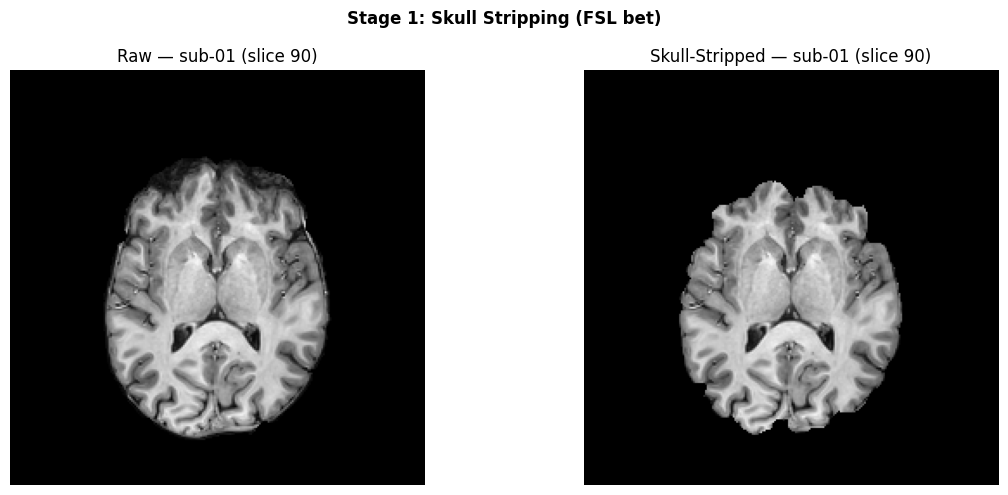

In [5]:

import nibabel as nib
import matplotlib.pyplot as plt

raw  = nib.load('data/raw/sub-01_T1w.nii').get_fdata()
proc = nib.load('data/processed/sub-01_T1w_brain.nii.gz').get_fdata()

mid = raw.shape[2] // 2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(raw[:, :, mid].T,  cmap='gray', origin='lower')
axes[0].set_title(f'Raw — sub-01 (slice {mid})')
axes[0].axis('off')

axes[1].imshow(proc[:, :, mid].T, cmap='gray', origin='lower')
axes[1].set_title(f'Skull-Stripped — sub-01 (slice {mid})')
axes[1].axis('off')

plt.suptitle('Stage 1: Skull Stripping (FSL bet)', fontweight='bold')
plt.tight_layout()
plt.savefig('models/stage1_comparison.png', dpi=150)
plt.show()

## Stage 2 — Slice Extraction

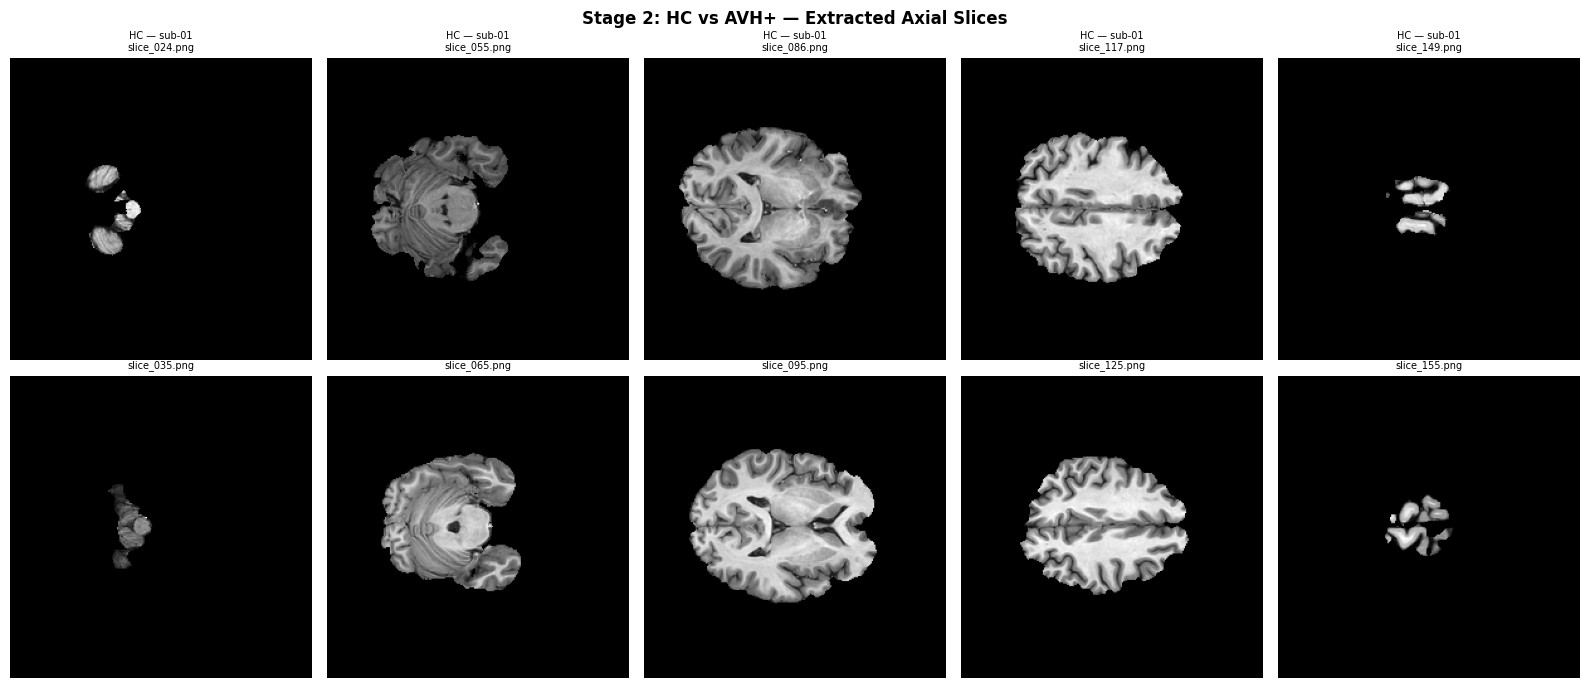

In [6]:

import os
import numpy as np
from PIL import Image

SLICES = 'data/slices'

hc_dir  = os.path.join(SLICES, 'sub-01_T1w')
avh_dir = os.path.join(SLICES, 'sub-73_T1w')

hc_files  = sorted(f for f in os.listdir(hc_dir)  if f.endswith('.png'))
avh_files = sorted(f for f in os.listdir(avh_dir) if f.endswith('.png'))

hc_pick  = [hc_files[i]  for i in np.linspace(0, len(hc_files)  - 1, 5, dtype=int)]
avh_pick = [avh_files[i] for i in np.linspace(0, len(avh_files) - 1, 5, dtype=int)]

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for col, (hf, af) in enumerate(zip(hc_pick, avh_pick)):
    for row, (d, f, lbl) in enumerate([(hc_dir, hf, 'HC — sub-01'), (avh_dir, af, 'AVH+ — sub-73')]):
        img = Image.open(os.path.join(d, f))
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].set_title(f'{lbl}\n{f}', fontsize=7)
        axes[row][col].axis('off')

plt.suptitle('Stage 2: HC vs AVH+ — Extracted Axial Slices', fontweight='bold')
plt.tight_layout()
plt.savefig('models/stage2_hc_vs_avh.png', dpi=150)
plt.show()


## Stage 3: Show dataset loading

In [7]:
import sys
sys.path.insert(0, '.')
from preprocessing.dataset import BrainSliceDataset

dataset = BrainSliceDataset('data/slices', 'data/participants.tsv')
img, label = dataset[0]

print(f'Total samples : {len(dataset)}')
print(f'Tensor shape  : {tuple(img.shape)}  (C x H x W)')
print(f'Pixel range   : [{img.min():.3f}, {img.max():.3f}]')
print(f'Label         : {label}  (0=HC, 1=AVH+)')

all_labels = [dataset[i][1] for i in range(len(dataset))]
print(f'Class balance : HC={all_labels.count(0)}, AVH+={all_labels.count(1)}')


Dataset ready: 1277 slices
Total samples : 1277
Tensor shape  : (1, 128, 128)  (C x H x W)
Pixel range   : [0.000, 0.569]
Label         : 1  (0=HC, 1=AVH+)
Class balance : HC=639, AVH+=638


## Training output

Dataset ready: 1260 slices
Epoch  1/10 | Loss: 22.2022 | Val Accuracy: 54.69%
Epoch  2/10 | Loss: 21.4641 | Val Accuracy: 56.64%
Epoch  3/10 | Loss: 20.9472 | Val Accuracy: 57.81%
Epoch  4/10 | Loss: 20.3203 | Val Accuracy: 58.59%
Epoch  5/10 | Loss: 19.4103 | Val Accuracy: 63.67%
Epoch  6/10 | Loss: 17.2019 | Val Accuracy: 73.44%
Epoch  7/10 | Loss: 14.3278 | Val Accuracy: 75.78%
Epoch  8/10 | Loss: 12.9138 | Val Accuracy: 77.73%
Epoch  9/10 | Loss: 11.1008 | Val Accuracy: 82.03%
Epoch 10/10 | Loss:  9.4129 | Val Accuracy: 88.28%

Model saved → models/brain_cnn.pth
Metrics saved → models/history.json

In [12]:
## Show the visualisation outputs

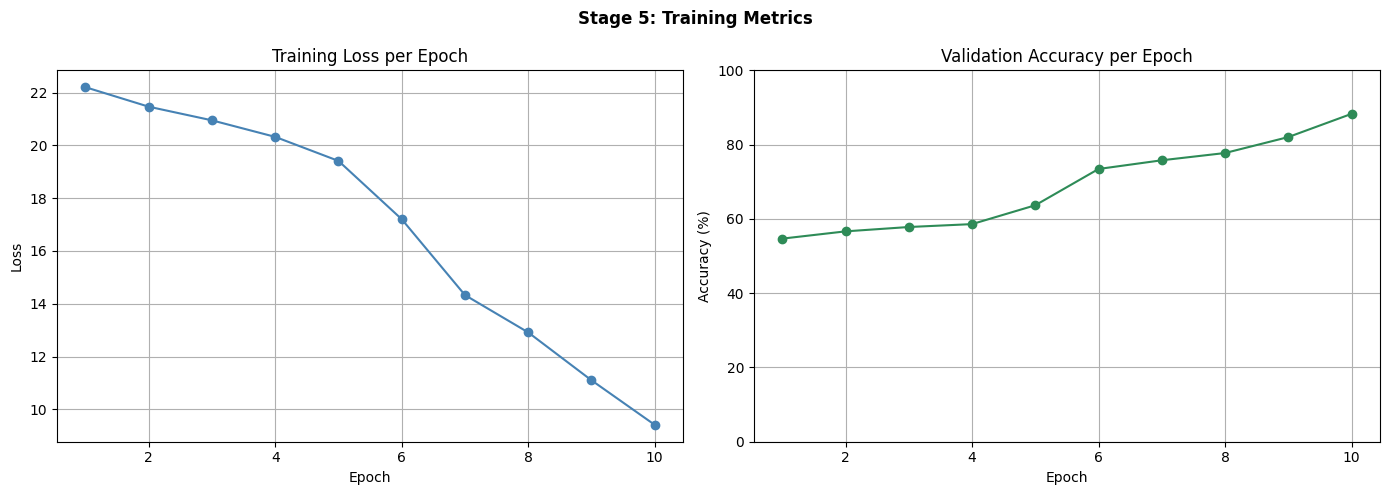

In [11]:
import json
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

with open('models/history.json') as f:
    history = json.load(f)

epochs = range(1, len(history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs, history['loss'], marker='o', color='steelblue')
axes[0].set_title('Training Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(True)

axes[1].plot(epochs, history['val_accuracy'], marker='o', color='seagreen')
axes[1].set_title('Validation Accuracy per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_ylim(0, 100); axes[1].grid(True)

plt.suptitle('Stage 5: Training Metrics', fontweight='bold')
plt.tight_layout()
plt.show()




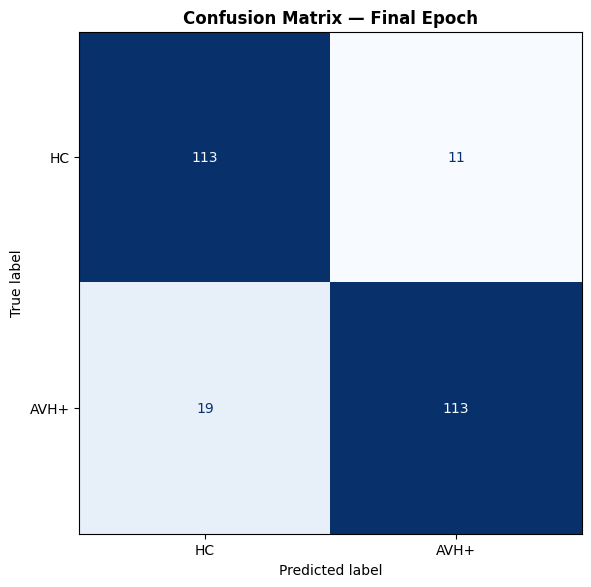

In [13]:
cm = confusion_matrix(history['val_labels'], history['val_preds'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['HC', 'AVH+'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Final Epoch', fontweight='bold')
plt.tight_layout()
plt.show()

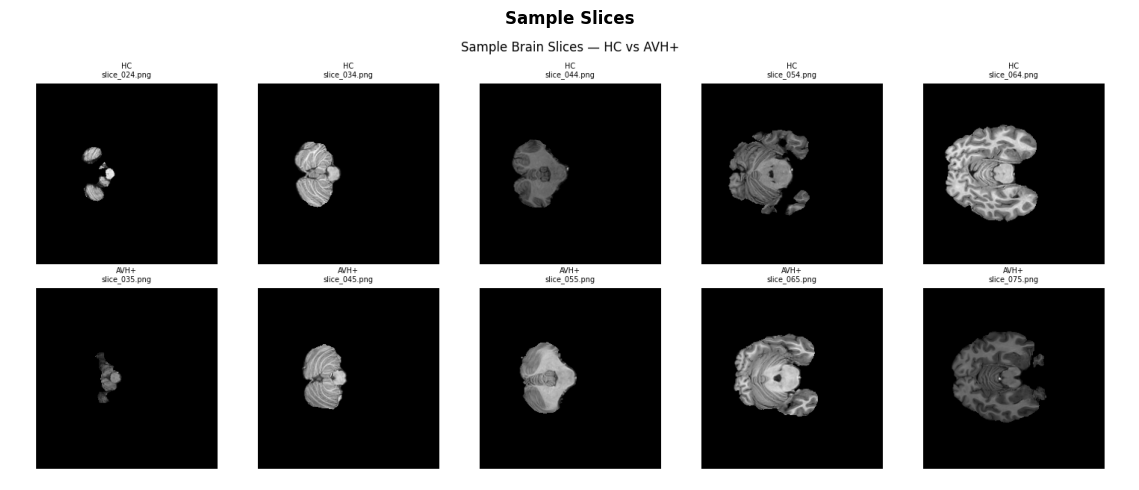

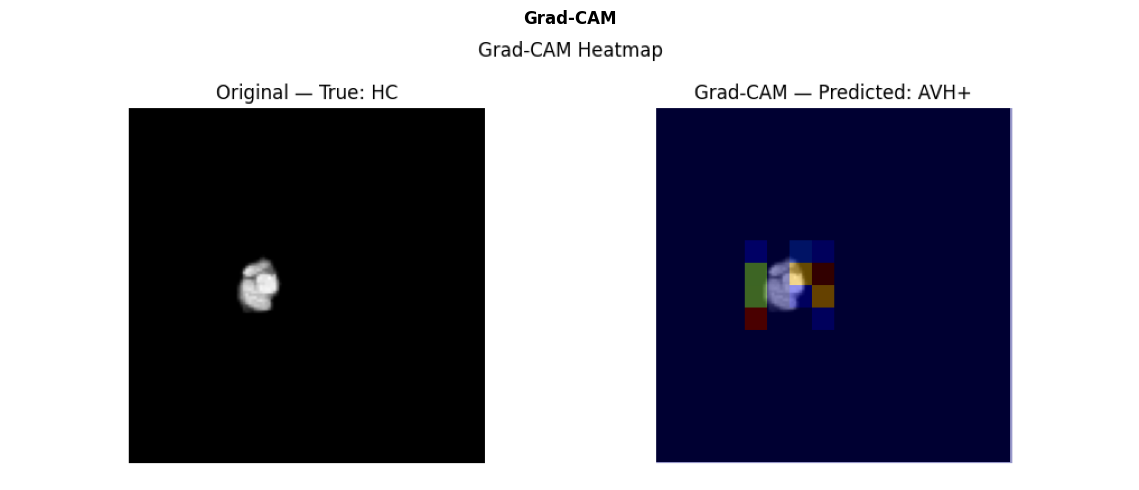

In [14]:
for path, title in [('models/sample_slices.png', 'Sample Slices'), ('models/gradcam.png', 'Grad-CAM')]:
    img = Image.open(path)
    plt.figure(figsize=(14, 5))
    plt.imshow(img); plt.title(title, fontweight='bold'); plt.axis('off')
    plt.tight_layout(); plt.show()

## Summary table

| Stage | Input | Output | Result |
|---|---|---|---|
| 1. Skull stripping | 10 × raw `.nii` | 10 × `_brain.nii.gz` | FSL bet -f 0.5 |
| 2. Slice extraction | 10 volumes | 1,260 × `.png` | 126 slices/subject |
| 3. Dataset loading | 1,260 PNGs | Labelled tensors (128×128) | HC=0, AVH+=1 |
| 4. Training | Tensors, 80/20 split | `brain_cnn.pth` | 88.28% val accuracy |
| 5. Visualisation | history.json + model | Loss, CM, Grad-CAM | Saved to `models/` |